In [1]:
pip install pymupdf

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install pdfplumber

   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   -------------- ------------------------- 2.4/6.6 MB 13.4 MB/s eta 0:00:01
   ------------------------------ --------- 5.0/6.6 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ------------------------------ --------- 2.6/3.5 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------- ----------- 2.6/3.7 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 12.3 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [cryptography]
   -------------------- ------------------- 2/4 [pdfminer.six]
   -------------------- ------------------- 2/4 [pdfminer.six]
   ---------------------------------------- 4/4 [pdfplumber]

Note: you m

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import glob, os, pdfplumber, fitz
import re
from datetime import datetime
import nltk
nltk.download('punkt')
nltk.download('words')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet') 
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import pandas as pd
from collections import Counter 
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image  
import numpy as np 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from textblob import Word, TextBlob
import string
from sklearn.decomposition import LatentDirichletAllocation
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_d

True

In [2]:
texts = []
# to run this code please include the path to the folder with documents labeled Ukraine
for file in glob.glob(r"Data\UkraineDocuments\*.pdf"):
    print(f"Reading {file}")
    doc = fitz.open(file)
    pages_text = []
    for page in doc:
       text = page.get_text()
       pages_text.append(text)
    texts.append(pages_text)
    doc.close()

Reading Data\UkraineDocuments\2024-03-20 OHCHR Report on Occupation and Aftermath_EN.pdf
Reading Data\UkraineDocuments\2024-03-26 OHCHR 38th Periodic Report.pdf
Reading Data\UkraineDocuments\2024-10-01 OHCHR 40th periodic report on Ukraine.pdf
Reading Data\UkraineDocuments\2025-03-21 OHCHR Report on Children's Rights in Ukraine.pdf
Reading Data\UkraineDocuments\2025-06-30 OHCHR 42nd periodic report on Ukraine_2.pdf
Reading Data\UkraineDocuments\2025-09-22 Treatment of civilians_ENG.pdf
Reading Data\UkraineDocuments\23-12-12-OHCHR-37th-periodic-report-ukraine-en.pdf
Reading Data\UkraineDocuments\A_77_220-EN.pdf
Reading Data\UkraineDocuments\A_78_340-EN.pdf
Reading Data\UkraineDocuments\A_79_258-EN.pdf
Reading Data\UkraineDocuments\A_HRC_53_64-EN.pdf
Reading Data\UkraineDocuments\A_HRC_59_67 ENG.pdf
Reading Data\UkraineDocuments\N2312781.pdf
Reading Data\UkraineDocuments\N2411029.pdf
Reading Data\UkraineDocuments\n2521410.pdf


In [3]:
# Cleaning the texts
for j in range(len(texts)):
    if j in [7,8,9,10,11,14]:   # National assembly reports first pages removal of unnecessary information
        texts[j][0] = re.split(r'Summary', texts[j][0])[-1]
    if j in [12, 13]:  # Reports by Security Council first pages removal of unnecessary information
        texts[j][0] = re.split(r'Report of the Secretary-General', texts[j][0])[-1]
    for i in range(len(texts[j])):
        if j in [0,1,2,3,4,5,6,10,11]:  # Remove notes from texts by United Nations Human Rights Office of the High Commisioner and A/HRC documents
            texts[j][i] = re.split(r'\n \n\d+', texts[j][i])[0]
            texts[j][i] = re.sub(r'Report on the Russian Occupation of Ukraine and its Aftermath','', texts[j][i])
            texts[j][i] = re.sub(r'\.{2,}','', texts[j][i])
        texts[j][i] = re.split(r'\n__________________ \n', texts[j][i])[0]
        texts[j][i] = re.split(r'\n__________________ \n', texts[j][i])[0]
        texts[j][i] = re.sub(r'/d+-/d+', '', texts[j][i])
        texts[j][i] = re.sub(r'\s+',' ', texts[j][i]).strip()
        texts[j][i] = re.sub(r'[*“”|©@#$%]', '',texts[j][i])
        texts[j][i] = re.sub(r'\d+\.', '',texts[j][i])
        texts[j][i] = re.sub(r'\d+', '',texts[j][i])
        texts[j][i] = re.sub(r'\(\s*\)', '', texts[j][i])
        texts[j][i] = re.sub(r'A//', '',texts[j][i])
        texts[j][i] = re.sub(r'/', '',texts[j][i])
        texts[j][i] = re.sub(r' \- ', '',texts[j][i])
        texts[j][i] = re.sub(r'\b[IVXLCDM]+\.', '', texts[j][i])
        texts[j][i] = re.sub(r'\([a-zA-Z]\)\s*', '', texts[j][i])
        texts[j][i] = re.sub(r'\s+',' ', texts[j][i]).strip()
        texts[j][i] = texts[j][i].strip()
for k in range(len(texts)):
    texts[k] = [x for x in texts[k] if x.strip()] 
    
# Specific problems for some documents: 
texts[0][31] = re.split(r"of collectivisation of agriculture", texts[0][31])[0]
texts[3][:] = texts[3][:26]

In [4]:
# very hard to extract all the titles and dates directly from the documents as the documents had different formats
titles = [
    'HUMAN RIGHTS SITUATION DURING THE RUSSIAN OCCUPATION OF TERRITORY OF UKRAINE AND ITS AFTERMATH 24 February 2022 – 31 December 2023',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 December 2023 – 29 February 2024',
    'TREATMENT OF PRISONERS OF WAR AND UPDATE ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 June to 31 August 2024',
    'THE IMPACT OF THE ARMED CONFLICT AND OCCUPATION ON CHILDREN’S RIGHTS IN UKRAINE 24 February 2022 — 31 December 2024',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 December 2024 – 31 May 2025',
    'TREATMENT OF CIVILIANS DEPRIVED OF THEIR LIBERTY IN THE CONTEXT OF THE ARMED ATTACK BY THE RUSSIAN FEDERATION AGAINST UKRAINE',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 August to 30 November 2023',
    'A/77/220 - 25 July 2022',
    'A/78/340 - 1 September 2023',
    'A/79/258 - 30 July 2024',
    'A/HRC/53/64 - 26 May 2023',
    'A/HRC/59/67 - 28 May 2025',
    'S/2023/413 - 22 June 2023',
    'S/2024/385 - 14 May 2024',
    'A/80/315 - 6 August 2025'
]
dates = [
    datetime(2024,3,20),
    datetime(2024,3,26),
    datetime(2024,10,1),
    datetime(2025,3,21),
    datetime(2025,6,30),
    datetime(2024,9,22),
    datetime(2023,12,12),
    datetime(2022,7,25),
    datetime(2023,9,1),
    datetime(2024,7,30),
    datetime(2023,5,26),
    datetime(2025,5,28),
    datetime(2023,6,22),
    datetime(2024,5,14),
    datetime(2025,8,6),
]

In [5]:
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith("N"):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

rows = []
for i in range(len(texts)):
    text = ''.join(texts[i])
    sentences = nltk.sent_tokenize(text)
    words = [nltk.word_tokenize(sentence) for sentence in sentences]
    pos_tagged_words = [nltk.pos_tag(word_list) for word_list in words]
    lemmatized_words = []
    for sentence in pos_tagged_words:
        lemmatized_sentence = []
        for word, pos in sentence:
            lemmatized_word = lemmatizer.lemmatize(word.lower(), get_wordnet_pos(pos))
            lemmatized_sentence.append((lemmatized_word, pos))
        lemmatized_words.extend(lemmatized_sentence)
    stop_words = set(nltk.corpus.stopwords.words('english'))
    custom_stop_words = {
    "access","address","affect","aid","area","assistance","authority",
    "case","community","council","crisis","delegate","discuss","emphasize",
    "express","further","government","ground","highlight","humanitarian",
    "include","information","international","issue","mandate","mechanism",
    "meeting","monitoring", "moscow","need","note","ohchr","ongoing", 
    "one","party","provide","public","region","remark","report","representative",
    "response","russia","russian","security","security council","session",
    "situation","statement","stress","support","territory","ukraine","ukrainian",
    "underscore","un","urge","welcome", "federation"}
    stop_words.update(custom_stop_words)
    filtered_words = [(word,pos) for word, pos in lemmatized_words if word not in stop_words] 
    final_filtered_words = []
    for word,pos in filtered_words:
        cleaned_word = re.sub(r'[^a-zA-Z0-9\s]','', word)
        if cleaned_word:
            final_filtered_words.append((cleaned_word,pos))
    all_words = [word for word, pos in final_filtered_words]
    most_common_words = Counter(all_words).most_common(20)
    processed_text = " ".join(all_words)
    nouns = [word for word,pos in final_filtered_words if pos.startswith('NN')]
    verbs = [word for word,pos in final_filtered_words if pos.startswith('VB')]
    adjectives = [word for word,pos in final_filtered_words if pos.startswith('JJ')]
    most_common_nouns = Counter(nouns).most_common(20)
    most_common_verbs = Counter(verbs).most_common(20)
    most_common_adjectives = Counter(adjectives).most_common(20)
    rows.append({
        'Title' : titles[i],
        'Date': dates[i],
        'Text': text, 
        'Tokenized sentences': sentences, 
        'Tokenized words': words,
        'Lemmatized words': lemmatized_words, 
        'Filtered words': final_filtered_words, 
        'All words list': all_words,
        'Processed text': processed_text,
        'Most Common words': most_common_words,
        'Nouns': nouns, 
        'Most Common Nouns': most_common_nouns,
        'Verbs': verbs, 
        'Most Common verbs': most_common_verbs, 
        'Adjectives': adjectives, 
        'Most Common Adjective': most_common_adjectives
    })
dataframe = pd.DataFrame(rows).sort_values(by='Date')

In [6]:
dataframe = dataframe.reset_index(drop=True)
dataframe

,Title,Date,Text,Tokenized sentences,Tokenized words,Lemmatized words,Filtered words,All words list,Processed text,Most Common words,Nouns,Most Common Nouns,Verbs,Most Common verbs,Adjectives,Most Common Adjective
0,A/77/220 - 25 July 2022,2022-07-25,The present report is submitted pursuant to Ge...,[The present report is submitted pursuant to G...,"[[The, present, report, is, submitted, pursuan...","[(the, DT), (present, JJ), (report, NN), (be, ...","[(present, JJ), (submit, VBN), (pursuant, NN),...","[present, submit, pursuant, general, assembly,...",present submit pursuant general assembly resol...,"[(crimea, 71), (right, 67), (court, 44), (huma...","[pursuant, general, assembly, resolution, asse...","[(crimea, 71), (right, 65), (court, 44), (law,...","[submit, request, make, improve, submit, occup...","[(occupy, 16), (convict, 13), (ensure, 11), (f...","[present, secretarygeneral, seventy, seventh, ...","[(human, 30), (military, 13), (religious, 12),..."
1,A/HRC/53/64 - 26 May 2023,2023-05-26,"In the present interim report, the Secretary-G...","[In the present interim report, the Secretary-...","[[In, the, present, interim, report, ,, the, S...","[(in, IN), (the, DT), (present, JJ), (interim,...","[(present, JJ), (interim, JJ), (secretarygener...","[present, interim, secretarygeneral, describe,...",present interim secretarygeneral describe prog...,"[(crimea, 83), (right, 68), (human, 42), (asse...","[progress, implementation, general, assembly, ...","[(crimea, 83), (right, 65), (assembly, 26), (d...","[describe, make, improve, reach, publish, owe,...","[(continue, 15), (arm, 15), (document, 14), (o...","[present, interim, secretarygeneral, present, ...","[(human, 36), (military, 16), (foreign, 12), (..."
2,S/2023/413 - 22 June 2023,2023-06-22,"Introduction The present report, which covers ...","[Introduction The present report, which covers...","[[Introduction, The, present, report, ,, which...","[(introduction, NNP), (the, DT), (present, JJ)...","[(introduction, NNP), (present, JJ), (cover, V...","[introduction, present, cover, period, january...",introduction present cover period january dece...,"[(sexual, 334), (violence, 323), (woman, 168),...","[introduction, period, january, december, reso...","[(violence, 322), (woman, 168), (force, 99), (...","[cover, submit, request, recommend, escalate, ...","[(continue, 51), (arm, 44), (ensure, 34), (com...","[present, pursuant, strategic, unconstitutiona...","[(sexual, 318), (conflictrelated, 111), (natio..."
3,A/78/340 - 1 September 2023,2023-09-01,"In the present report, the Secretary-General d...","[In the present report, the Secretary-General ...","[[In, the, present, report, ,, the, Secretary-...","[(in, IN), (the, DT), (present, JJ), (report, ...","[(present, JJ), (secretarygeneral, JJ), (descr...","[present, secretarygeneral, describe, progress...",present secretarygeneral describe progress mak...,"[(crimea, 90), (right, 55), (human, 37), (dete...","[progress, implementation, general, assembly, ...","[(crimea, 90), (right, 55), (detention, 33), (...","[describe, make, improve, submit, occupy, subm...","[(document, 25), (occupy, 16), (transfer, 16),...","[present, secretarygeneral, present, recent, p...","[(human, 32), (military, 26), (temporary, 14),..."
4,REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...,2023-12-12,Photo cover page Heavily damaged building of t...,[Photo cover page Heavily damaged building of ...,"[[Photo, cover, page, Heavily, damaged, buildi...","[(photo, NNP), (cover, NN), (page, NN), (heavi...","[(photo, NNP), (cover, NN), (page, NN), (heavi...","[photo, cover, page, heavily, damage, building...",photo cover page heavily damage building emerg...,"[(civilian, 55), (right, 54), (men, 45), (huma...","[photo, cover, page, heavily, building, emerge...","[(right, 53), (men, 45), (pow, 41), (august, 3...","[damage, photograph, casualties, novemberrepor...","[(document, 34), (arm, 22), (occupy, 22), (kil...","[human, residential, explosive, administrative..

Text(0, 0.5, 'Count')

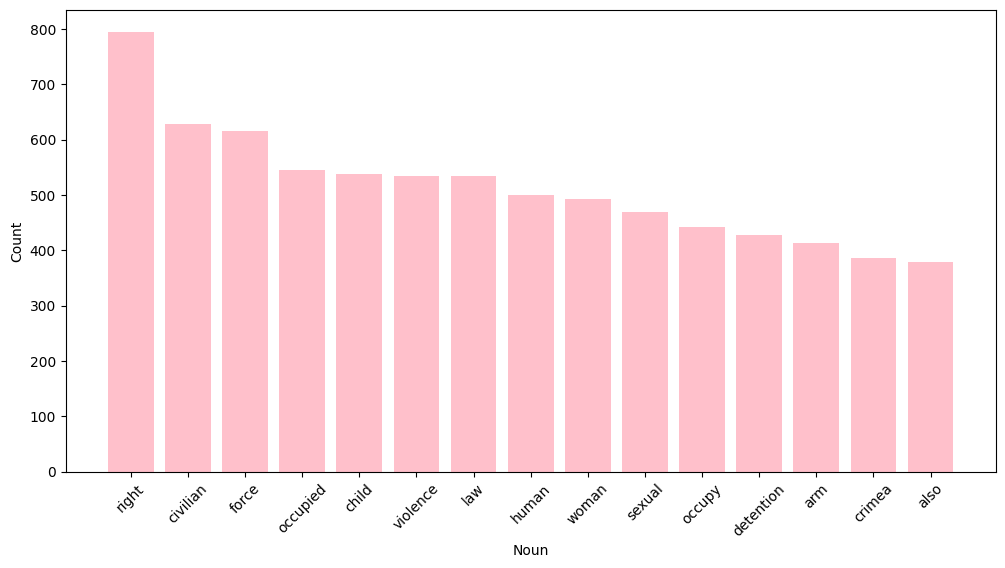

In [7]:
all_text = []
for i in dataframe['All words list']:
    all_text.extend(i)
most_common_words = Counter(all_text).most_common(15)
word_list, word_counts = zip(*most_common_words)
plt.figure(figsize=(12,6))
plt.bar(word_list, word_counts, color= 'pink')
plt.xticks(rotation=45) 
plt.xlabel("Noun")
plt.ylabel('Count')

<function matplotlib.pyplot.show(close=None, block=None)>

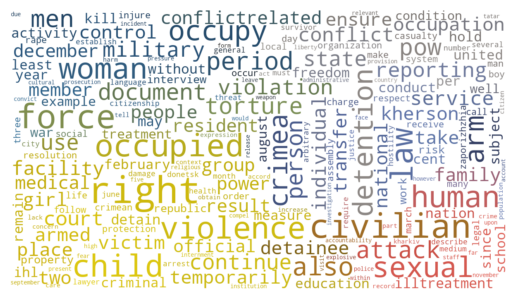

In [8]:
pic = np.array(Image.open(r"Data\pic2.jpg"))
image_colors = ImageColorGenerator(pic)
word_freq = nltk.FreqDist(all_text)
wordcloud = WordCloud(width = 800, height=500, max_font_size=90, min_font_size=6, background_color='white',
                      color_func = image_colors, mask = pic)
plt.imshow(wordcloud.generate_from_frequencies(word_freq), interpolation = 'bilinear')
plt.axis('off')
plt.show

In [9]:
documents = [i for i in dataframe['Processed text']]

In [10]:
tfidf_vectorizer = TfidfVectorizer(lowercase = True)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
vocab = tfidf_vectorizer.get_feature_names_out()

In [11]:
tfidf_dataframe = pd.DataFrame(tfidf_matrix.toarray(), columns=vocab)

In [12]:
dataframe['Top words tf-idf'] = dataframe.index.to_series().apply(lambda i: tfidf_dataframe.iloc[i].nlargest(15).index.tolist())

In [13]:
dataframe[['Top words tf-idf']]

,Top words tf-idf
0,"[crimea, right, crimean, court, human, law, ta..."
1,"[crimea, right, human, ge, assembly, detention..."
2,"[sexual, violence, woman, conflictrelated, for..."
3,"[crimea, right, human, province, detention, tr..."
4,"[pow, civilian, right, oblast, men, august, gr..."
5,"[force, occupied, occupation, arm, occupy, res..."
6,"[pow, civilian, attack, right, december, febru..."
7,"[civilian, conflict, sudan, harm, protection, ..."
8,"[occupy, temporarily, crimea, control, right, ..."
9,"[detention, civilian, detainee, liberty, tortu..."


In [14]:
dataframe['polarity'] = dataframe['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
dataframe['subjectivity'] = dataframe['Text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [15]:
row_index = dataframe['subjectivity'].idxmax()
dataframe.loc[row_index]

Title                                            S/2023/413 - 22 June 2023
Date                                                   2023-06-22 00:00:00
Text                     Introduction The present report, which covers ...
Tokenized sentences      [Introduction The present report, which covers...
Tokenized words          [[Introduction, The, present, report, ,, which...
Lemmatized words         [(introduction, NNP), (the, DT), (present, JJ)...
Filtered words           [(introduction, NNP), (present, JJ), (cover, V...
All words list           [introduction, present, cover, period, january...
Processed text           introduction present cover period january dece...
Most Common words        [(sexual, 334), (violence, 323), (woman, 168),...
Nouns                    [introduction, period, january, december, reso...
Most Common Nouns        [(violence, 322), (woman, 168), (force, 99), (...
Verbs                    [cover, submit, request, recommend, escalate, ...
Most Common verbs        

In [16]:
dataframe['sentence with highest polarity'] = dataframe['Tokenized sentences'].apply(
    lambda sent_list: max([(s, TextBlob(s).sentiment.polarity) for s in sent_list], key=lambda x: x[1]))
dataframe['sentence with lowest polarity'] = dataframe['Tokenized sentences'].apply(
    lambda sent_list: min([(s, TextBlob(s).sentiment.polarity) for s in sent_list], key=lambda x: x[1]))
dataframe['sentence with highest subjectivity'] = dataframe['Tokenized sentences'].apply(
    lambda sent_list: max([(s, TextBlob(s).sentiment.subjectivity) for s in sent_list], key=lambda x: x[1]))

In [17]:
dataframe[['Title', 'polarity', 'subjectivity', 'sentence with highest subjectivity']]

,Title,polarity,subjectivity,sentence with highest subjectivity
0,A/77/220 - 25 July 2022,0.028565,0.285854,(The restrictions risk limiting access in Crim...
1,A/HRC/53/64 - 26 May 2023,0.037560,0.288870,(Five victims whose whereabouts eventually bec...
2,S/2023/413 - 22 June 2023,0.143570,0.456266,(While women and girls continueS to constitute...
3,A/78/340 - 1 September 2023,0.030728,0.281136,(Although the court examined some of these iss...
4,REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...,0.043998,0.298961,(Ukrainian children continued to face disrupte...
5,HUMAN RIGHTS SITUATION DURING THE RUSSIAN OCCU...,0.023607,0.283987,(OHCHR abided strictly by the obligations to ‘...
6,REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...,0.020296,0.299876,(The war continued to cause devastating civili...
7,S/2024/385 - 14 May 2024,0.067668,0.350394,(The state of the protection of civilians in w...
8,A/79/258 - 30 July 2024,0.044235,0.275549,(The occupying authorities only acknowledged t...
9,TREATMENT OF CIVILIANS DEPRIVED OF THEIR LIBER...,0.031643,0.327505,(States are obliged to take all necessary meas...


In [18]:
dataframe.loc[row_index]['sentence with highest subjectivity']

('While women and girls continueS to constitute the vast majority of victims, men, boys and gender non-conforming persons are also affected.',
 1.0)

In [19]:
RANDOM_STATE = 42

In [20]:
vectorizer = CountVectorizer(max_df = 0.9, min_df = 2, stop_words = 'english')
dtm = vectorizer.fit_transform(documents)
vocab = vectorizer.get_feature_names_out()
print("DTM SHAPE (doc, terms):", dtm.shape)
print("first 20 vocab:", vocab[:20])

DTM SHAPE (doc, terms): (15, 2756)
first 20 vocab: ['aa' 'abandon' 'abduct' 'abducted' 'abduction' 'abide' 'ability'
 'abolish' 'abroad' 'absence' 'absent' 'absentia' 'absolute' 'absolutely'
 'absolve' 'abuse' 'abusive' 'academic' 'accelerate' 'accept']


In [21]:
num_topics = 4
lda = LatentDirichletAllocation(n_components = num_topics, 
                                max_iter = 20, learning_method = 'batch', 
                                random_state = RANDOM_STATE)
lda.fit(dtm)

,n_components,4
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,20
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [22]:
def print_topics(lda_model, vocab, topn=10):
    for topic_idx, topic_weights in enumerate(lda_model.components_):
        top_indices = topic_weights.argsort()[-topn:]  # largest weights
        top_terms = [vocab[i] for i in top_indices][::-1]
        print(f"Topic {topic_idx+1}: {'  '.join(top_terms)}\n")

print_topics(lda, vocab, topn=20)

Topic 1: detainee  kherson  ihl  kharkiv  liberty  collaboration  search  tell  deprive  staff  context  zaporizhzhia  home  ihrl  beat  passport  conflictrelated  cultural  soldier  checkpoint

Topic 2: crimea  child  temporarily  education  school  reporting  crimean  property  kherson  language  tatar  expression  citizenship  medium  citizen  detainee  zaporizhzhia  class  arrest  federal

Topic 3: pow  reporting  child  kill  casualty  august  injure  ihl  girl  internment  interview  damage  frontline  donetsk  strike  hostility  weapon  kherson  city  execution

Topic 4: conflictrelated  girl  protection  rape  survivor  child  sudan  harm  crime  actor  incident  special  displacement  peace  million  congo  commit  accountability  democratic  kill



In [23]:
doc_topic = lda.transform(dtm)
doc_topic_df = pd.DataFrame(doc_topic, columns=[f"Topic_{i+1}" for i in range(num_topics)])
doc_topic_df.index=[f"Doc{i+1}" for i in range(len(documents))]
doc_topic_df.round(3)

,Topic_1,Topic_2,Topic_3,Topic_4
Doc1,0.000,1.000,0.000,0.000
Doc2,0.000,1.000,0.000,0.000
Doc3,0.000,0.000,0.000,1.000
Doc4,0.000,1.000,0.000,0.000
Doc5,0.000,0.000,1.000,0.000
Doc6,0.589,0.353,0.058,0.000
Doc7,0.000,0.000,1.000,0.000
Doc8,0.000,0.000,0.000,1.000
Doc9,0.000,1.000,0.000,0.000
Doc10,1.000,0.000,0.000,0.000


In [24]:
dataframe['Dominant Topic'] = doc_topic.argmax(axis=1) + 1
dataframe[['Title','Date','Dominant Topic']]

,Title,Date,Dominant Topic
0,A/77/220 - 25 July 2022,2022-07-25,2
1,A/HRC/53/64 - 26 May 2023,2023-05-26,2
2,S/2023/413 - 22 June 2023,2023-06-22,4
3,A/78/340 - 1 September 2023,2023-09-01,2
4,REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...,2023-12-12,3
5,HUMAN RIGHTS SITUATION DURING THE RUSSIAN OCCU...,2024-03-20,1
6,REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...,2024-03-26,3
7,S/2024/385 - 14 May 2024,2024-05-14,4
8,A/79/258 - 30 July 2024,2024-07-30,2
9,TREATMENT OF CIVILIANS DEPRIVED OF THEIR LIBER...,2024-09-22,1


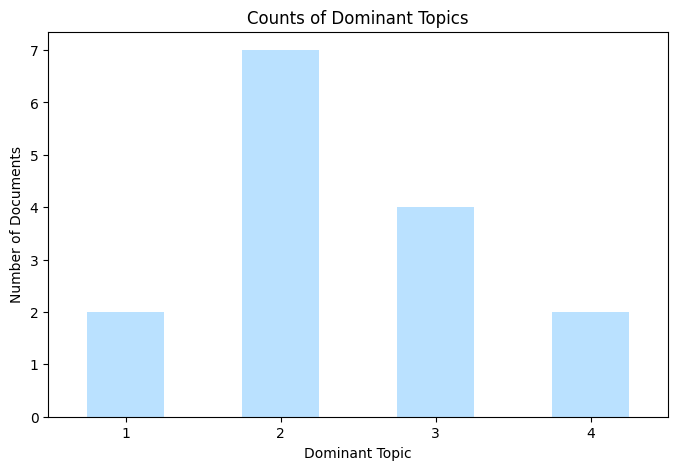

In [25]:
# Count how many times each topic appears
topic_counts = dataframe['Dominant Topic'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='#BAE1FF')

plt.title('Counts of Dominant Topics')
plt.xlabel('Dominant Topic')
plt.ylabel('Number of Documents')
plt.xticks(rotation=0)
plt.show()

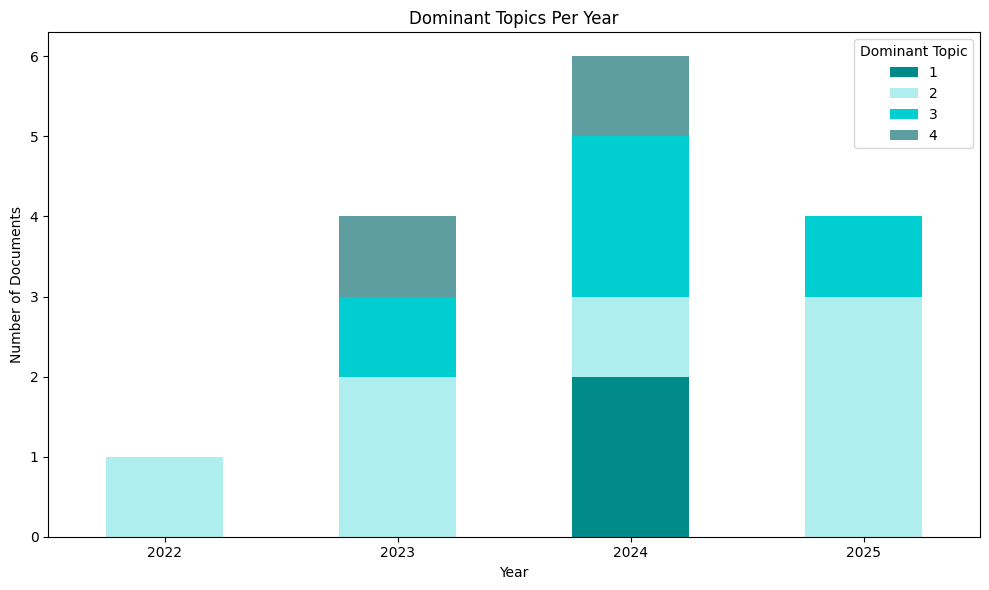

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

dataframe['Year'] = dataframe['Date'].dt.year
topic_year = dataframe.groupby(['Year', 'Dominant Topic']).size().unstack(fill_value=0)
colors = {1: 'darkcyan', 2: 'paleturquoise', 3: 'darkturquoise', 4: 'cadetblue'} 
bar_colors = [colors.get(topic, 'gray') for topic in topic_year.columns]
ax = topic_year.plot(kind='bar', stacked=True, color=bar_colors, figsize=(10,6))

plt.title('Dominant Topics Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Documents')
ax.set_xticklabels(topic_year.index.astype(str), rotation=0)
plt.legend(title='Dominant Topic')
plt.tight_layout()
plt.show()


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

np.random.seed(RANDOM_STATE)

In [28]:
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2) 
X = vectorizer.fit_transform(documents)
vocab = vectorizer.get_feature_names_out()
print("\nTF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (15, 2851)


In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, init='k-means++', max_iter=300, random_state=0)
    labels = kmeans.fit_predict(X)
    sil = silhouette_score(X,labels)
    silhouette_scores.append(sil)

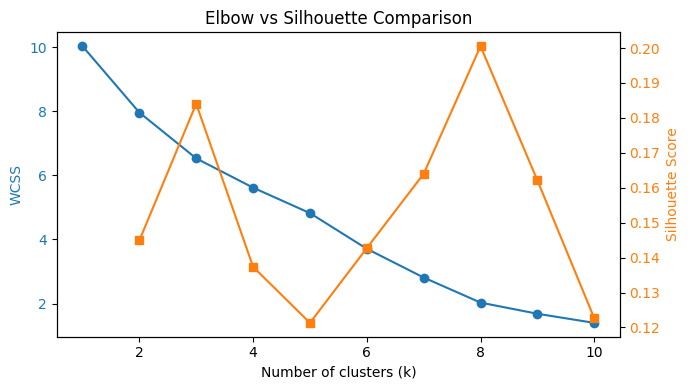

In [30]:
# 7) Compare Elbow and Silhouette visually
fig, ax1 = plt.subplots(figsize=(7, 4))

# ---- Elbow (WCSS) on the left y-axis ----
ax1.plot(range(1, 11), wcss, color='tab:blue', marker='o', label='WCSS (Elbow)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# ---- Silhouette on the right y-axis ----
ax2 = ax1.twinx()
ax2.plot(range(2, 11), silhouette_scores, color='tab:orange', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Elbow vs Silhouette Comparison')
fig.tight_layout()
plt.show()


In [31]:
best_k = 5

kmeans = KMeans(n_clusters = best_k, n_init= 10, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X)
dataframe['cluster']=labels
print(dataframe[['Title','cluster']])

                                                Title  cluster
0                             A/77/220 - 25 July 2022        0
1                           A/HRC/53/64 - 26 May 2023        0
2                           S/2023/413 - 22 June 2023        2
3                         A/78/340 - 1 September 2023        0
4   REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...        1
5   HUMAN RIGHTS SITUATION DURING THE RUSSIAN OCCU...        3
6   REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...        1
7                            S/2024/385 - 14 May 2024        2
8                             A/79/258 - 30 July 2024        4
9   TREATMENT OF CIVILIANS DEPRIVED OF THEIR LIBER...        3
10  TREATMENT OF PRISONERS OF WAR AND UPDATE ON TH...        1
11  THE IMPACT OF THE ARMED CONFLICT AND OCCUPATIO...        3
12                          A/HRC/59/67 - 28 May 2025        4
13  REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAIN...        1
14                           A/80/315 - 6 August 2025  

In [32]:
def top_terms_per_cluster(model, vocab, topn=50):    
    centers = model.cluster_centers_  

    for c in range(centers.shape[0]):  
        top_idx = centers[c].argsort()[-topn:][::-1]  
        terms = [vocab[i] for i in top_idx]  
        print(f"\nCluster {c} top terms:\n  " + "  ".join(terms))  

print("\nTop words per cluster:")
top_terms_per_cluster(kmeans, vocab)  


Top words per cluster:

Cluster 0 top terms:
  crimea  crimean  tatar  federal  simferopol  citizen  boundary  reporting  arrest  ge  defendant  kherson  province  detainee  child  expression  pretrial  medium  sentence  draft  peaceful  opinion  disappearance  deny  officer  school  centre  fine  secretarygeneral  language  class  conviction  man  filtration  rouble  defender  outlet  liberty  student  ban  para  temporarily  peninsula  evasion  prison  foreign  documented  arbitrary  offensive  aim

Cluster 1 top terms:
  pow  reporting  ihl  casualty  kill  injure  august  internment  child  girl  frontline  missile  strike  interview  damage  munition  donetsk  oblast  november  many  kherson  kharkiv  execution  captivity  city  serviceman  hostility  detainee  uoc  weapon  describe  beating  incident  drone  interviewee  collaboration  citizenship  say  property  explosive  instance  man  impact  medium  capture  personnel  january  infrastructure  electric  oblasts

Cluster 2 t

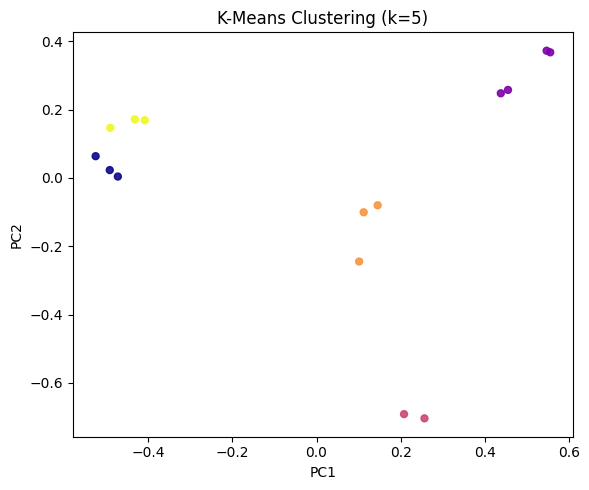

In [33]:
# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X.toarray())

# Drawing
plt.figure(figsize=(6,5))

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=25, alpha=0.9,cmap="plasma",)
plt.title(f"K-Means Clustering (k={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()